# SKIPP'D — End-to-End 15-min PV Nowcasting

Every model (rule baselines, PV-only MLP, SUNSET CNN, existing Vanilla Transformer)
runs off **one shared DataModule**: the same day-level split, the same forecast
window index, the same scaler, and the same test samples. Each section runs on its
own; nothing trains on import.

All orchestration goes through `baseline_skippd.notebook_api` (thin wrappers) — the
Dataset, trainer, metrics, and Transformer are **not** re-implemented here.

## Section 0 — Environment and imports

In [5]:
import os, sys
REPO = "/Users/lin_/Solar_Prediction"
sys.path.insert(0, REPO)      # so `import src...` works
os.chdir(REPO)                # so relative paths (configs/, data/, artifacts/) resolve from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from src.baseline_skippd.notebook_api import (
    load_skippd_config, build_skippd_datamodule, build_model, build_model_adapter,
    train_model, evaluate_model, run_rule_baseline, compare_runs,
    load_existing_checkpoint, get_sample_batch,
)

## Section 1 — Load config

In [7]:
cfg = load_skippd_config("configs/skippd/vanilla_transformer_pv_only.yaml")
# For a quick pass, coarsen the train stride (fewer windows) and cap epochs:
cfg["window"]["strides"] = {"train": 12, "validation": 6, "test": 1}
cfg["trainer"]["max_epochs"] = 15
cfg

{'run_name': 'vt_pv_only',
 'seed': 42,
 'device': None,
 'verbose': True,
 'data': {'root': 'data/raw/SKIPPD'},
 'window': {'history_minutes': 15,
  'history_step_minutes': 1,
  'horizon_minutes': 15,
  'strides': {'train': 12, 'validation': 6, 'test': 1}},
 'split': {'strategy': 'chronological_day_holdout',
  'seed': 42,
  'val_frac': 0.15},
 'scaler': {'name': 'capacity', 'capacity_kw': 30.1},
 'model': {'name': 'vanilla_transformer',
  'd_model': 64,
  'nhead': 8,
  'num_layers': 2,
  'dim_ff': 128,
  'dropout': 0.1},
 'trainer': {'lr': 0.001,
  'weight_decay': 0.0001,
  'grad_clip': 1.0,
  'max_epochs': 15,
  'patience': 6,
  'batch_size': 256,
  'num_workers': 0},
 'eval': {'capacity_kw': 30.1},
 'clear_sky': {'quantile': 0.95, 'smooth': 15},
 'artifacts': {'dir': 'artifacts/skippd'},
 'config_hash': '4905da336bd71bc3'}

## Section 2 — Inspect processed data

In [8]:
from src.baseline_skippd import SKIPPDProcessedStore
store = SKIPPDProcessedStore(cfg["data"]["root"])
store.report()

{'trainval': {'group': 'trainval',
  'rows': 349372,
  'image_shape': (64, 64, 3),
  'image_dtype': 'uint8',
  'pv_dtype': 'float32',
  'pv_min': 1.9799999790848233e-05,
  'pv_max': 29.585369110107422,
  'negative_pv': 0,
  'timestamp_start': '2017-03-09 06:47:00-08:00',
  'timestamp_end': '2019-10-26 18:59:20-07:00',
  'duplicate_timestamps': 0,
  'non_monotonic_steps': 0,
  'gaps_over_1min': 719,
  'gaps_over_1day': 40,
  'largest_gap_minutes': 143365.83333333334},
 'test': {'group': 'test',
  'rows': 14003,
  'image_shape': (64, 64, 3),
  'image_dtype': 'uint8',
  'pv_dtype': 'float32',
  'pv_min': 9.509999654255807e-05,
  'pv_max': 29.570940017700195,
  'negative_pv': 0,
  'timestamp_start': '2017-06-24 07:38:40-07:00',
  'timestamp_end': '2019-10-19 19:15:30-07:00',
  'duplicate_timestamps': 0,
  'non_monotonic_steps': 0,
  'gaps_over_1min': 34,
  'gaps_over_1day': 19,
  'largest_gap_minutes': 175037.0}}

## Section 3 — Build the shared DataModule and review the split manifest

In [9]:
dm = build_skippd_datamodule(cfg)
dm.setup()
m = dm.split_manifest
print("strategy:", m.strategy, "| hash:", m.config_hash)
print(f"train days {len(m.train_dates)} | val days {len(m.validation_dates)} | test days {len(m.test_dates)}")
print("trainval ∩ test:", m.trainval_test_overlap)

strategy: chronological_day_holdout | hash: 8aaabdf1b5040371
train days 422 | val days 75 | test days 20
trainval ∩ test: []


## Section 4 — Review window statistics

In [10]:
wi = dm.window_index
print("total windows:", len(wi), "| T =", wi.T, "(t-15..t)")
for s in ["train", "validation", "test"]:
    print(f"  {s:11s}: {len(wi.subset(s)):>6} windows")

total windows: 35857 | T = 16 (t-15..t)
  train      :  18247 windows
  validation :   6524 windows
  test       :  11086 windows


## Section 5 — Visualize one sample

{'images': (256, 16, 3, 64, 64), 'pv_history': (256, 16), 'target': (256, 1), 'issue_time': (256,), 'target_time': (256,), 'sample_index': (256,)}


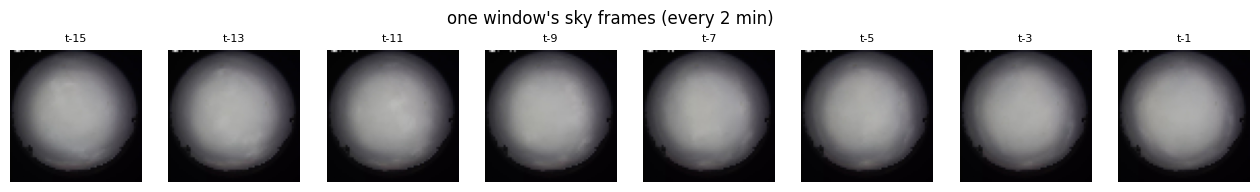

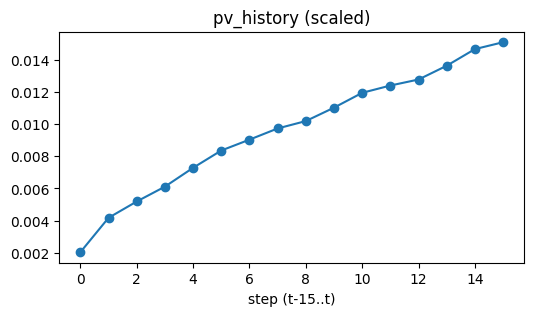

In [11]:
batch = get_sample_batch(dm, "test")
print({k: (tuple(v.shape) if hasattr(v, "shape") else v) for k, v in batch.items() if k != "split"})
imgs = batch["images"][0]          # [T, C, H, W]
fig, ax = plt.subplots(1, 8, figsize=(16, 2.2))
for j in range(8):
    ax[j].imshow(imgs[j * 2].permute(1, 2, 0).numpy()); ax[j].axis("off")
    ax[j].set_title(f"t-{15 - j*2}", fontsize=8)
plt.suptitle("one window's sky frames (every 2 min)"); plt.show()
plt.figure(figsize=(6, 3)); plt.plot(batch["pv_history"][0].numpy(), marker="o")
plt.title("pv_history (scaled)"); plt.xlabel("step (t-15..t)"); plt.show()

## Section 6 — Naive Persistence

In [12]:
naive = run_rule_baseline("naive_persistence", dm, cfg)
naive["overall"]

/Users/lin_/Solar_Prediction/src/helper/metrics.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  day["_month"] = day[time_col].dt.to_period("M")


{'n': 11086,
 'rmse_kw': 3.7129366211045167,
 'mae_kw': 2.1162827683466907,
 'mbe_kw': -0.046826669161564846,
 'acc_rmse': 0.8766466238835708,
 'acc_mae': 0.9296916023805086}

## Section 7 — Clear-Sky Persistence

In [13]:
clear_sky = run_rule_baseline("clear_sky_persistence", dm, cfg)
clear_sky["overall"]

/Users/lin_/Solar_Prediction/src/helper/metrics.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  day["_month"] = day[time_col].dt.to_period("M")


{'n': 11086,
 'rmse_kw': 3.629782123934499,
 'mae_kw': 1.768339349149932,
 'mbe_kw': 0.006525567825770215,
 'acc_rmse': 0.8794092317629735,
 'acc_mae': 0.9412511844136235}

## Section 8 — Train PV-only MLP

In [14]:
mlp = build_model("pv_only", cfg, dm)
train_model(mlp, dm, cfg)
mlp_metrics = evaluate_model(mlp, dm, cfg)
mlp_metrics["overall"]

epoch   1 | train 0.01963 | val 0.00488  <- best
epoch   2 | train 0.01052 | val 0.00439  <- best
epoch   3 | train 0.00929 | val 0.00381  <- best
epoch   4 | train 0.00868 | val 0.00375  <- best
epoch   5 | train 0.00845 | val 0.00411
epoch   6 | train 0.00809 | val 0.00387
epoch   7 | train 0.00798 | val 0.00375  <- best
epoch   8 | train 0.00778 | val 0.00320  <- best
epoch   9 | train 0.00761 | val 0.00331
epoch  10 | train 0.00748 | val 0.00302  <- best
epoch  11 | train 0.00732 | val 0.00287  <- best
epoch  12 | train 0.00715 | val 0.00281  <- best
epoch  13 | train 0.00713 | val 0.00275  <- best
epoch  14 | train 0.00707 | val 0.00272  <- best
epoch  15 | train 0.00693 | val 0.00312


/Users/lin_/Solar_Prediction/src/helper/metrics.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  day["_month"] = day[time_col].dt.to_period("M")


{'n': 11086,
 'rmse_kw': 3.2812854229225326,
 'mae_kw': 1.8251134679468057,
 'mbe_kw': 0.04528028368700804,
 'acc_rmse': 0.8909871952517431,
 'acc_mae': 0.9393650010648902}

## Section 9 — Train SUNSET CNN

Uses the sky images (via the CNN adapter: [B,T,C,H,W] -> [B,48,64,64]). Heavy;
this is a short demonstration run, not the paper's 200-epoch schedule.

In [15]:
cfg_cnn = load_skippd_config("configs/skippd/sunset_forecast_dev.yaml")
cfg_cnn["window"]["strides"] = cfg["window"]["strides"]     # same windows as the others
cnn = build_model("sunset_forecast", cfg_cnn, dm)
print("params:", sum(p.numel() for p in cnn.parameters()))
train_model(cnn, dm, cfg_cnn)
cnn_metrics = evaluate_model(cnn, dm, cfg_cnn)
cnn_metrics["overall"]

params: 13671897
epoch   1 | train 0.05158 | val 0.02503  <- best
epoch   2 | train 0.02559 | val 0.00906  <- best
epoch   3 | train 0.02009 | val 0.00682  <- best


/Users/lin_/Solar_Prediction/src/helper/metrics.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  day["_month"] = day[time_col].dt.to_period("M")


{'n': 11086,
 'rmse_kw': 4.060477620871957,
 'mae_kw': 2.909523703742751,
 'mbe_kw': -1.0478609269644705,
 'acc_rmse': 0.8651004112667124,
 'acc_mae': 0.9033380829321345}

## Section 10 — Existing Vanilla Transformer (PV-only)

Reuses `src/vanilla_transformer` unchanged, driven through the adapter. **PV-only
(Case 1): it does NOT use the sky images.**

In [16]:
vt = build_model("vanilla_transformer", cfg, dm)
train_model(vt, dm, cfg)              # trains via the existing vanilla_transformer.Trainer
vt_metrics = evaluate_model(vt, dm, cfg)
vt_metrics["overall"]

epoch  1 | train 0.02209 | val 0.00493  <- best
epoch  2 | train 0.00751 | val 0.00285  <- best
epoch  3 | train 0.00671 | val 0.00261  <- best
epoch  4 | train 0.00619 | val 0.00252  <- best
epoch  5 | train 0.00627 | val 0.00263
epoch  6 | train 0.00594 | val 0.00251  <- best
epoch  7 | train 0.00577 | val 0.00241  <- best
epoch  8 | train 0.00571 | val 0.00254
epoch  9 | train 0.00613 | val 0.00263
epoch 10 | train 0.00570 | val 0.00389
epoch 11 | train 0.00560 | val 0.00268
epoch 12 | train 0.00570 | val 0.00263
epoch 13 | train 0.00556 | val 0.00302
early stop at epoch 13
best val loss: 0.00241


/Users/lin_/Solar_Prediction/src/helper/metrics.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  day["_month"] = day[time_col].dt.to_period("M")


{'n': 11086,
 'rmse_kw': 3.2113075519345924,
 'mae_kw': 1.7103314731752413,
 'mbe_kw': -0.1875161874115283,
 'acc_rmse': 0.893312041463967,
 'acc_mae': 0.9431783563729156}

## Section 11 — Compare metrics (same test set for all)

In [17]:
table = compare_runs([naive, clear_sky, mlp_metrics, cnn_metrics, vt_metrics])
table

,model,acc_rmse,acc_mae,rmse_kw,mae_kw,monthly_acc_rmse,n
0,vanilla_transformer,0.893312,0.943178,3.211308,1.710331,0.906958,11086
1,pv_only,0.890987,0.939365,3.281285,1.825113,0.902698,11086
2,clear_sky_persistence,0.879409,0.941251,3.629782,1.768339,0.894453,11086
3,naive_persistence,0.876647,0.929692,3.712937,2.116283,0.886304,11086
4,sunset_forecast,0.865100,0.903338,4.060478,2.909524,0.867204,11086


## Section 12 — Plot predictions (one test day)

In [18]:
preds = pd.read_parquet(f"artifacts/skippd/{cfg['run_name']}_vanilla_transformer/predictions.parquet")
day = preds.assign(d=preds.issue_time.dt.tz_convert("US/Pacific").dt.date)
one = day[day.d == day.d.unique()[0]].sort_values("issue_time")
plt.figure(figsize=(11, 4))
plt.plot(one.target_time, one.y_true_kw, label="actual", lw=1.4)
plt.plot(one.target_time, one.y_pred_kw, label="predicted", lw=1.2)
plt.legend(); plt.title("Transformer — one test day (15-min-ahead)"); plt.ylabel("kW"); plt.show()

/var/folders/0n/8dcl73995rb5cm8bcg4yxz5h0000gn/T/ipykernel_35032/2427022579.py:7: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.legend(); plt.title("Transformer — one test day (15-min-ahead)"); plt.ylabel("kW"); plt.show()


## Section 13 — Save summary

In [19]:
summary = compare_runs([naive, clear_sky, mlp_metrics, cnn_metrics, vt_metrics])
summary.to_csv("artifacts/skippd/comparison.csv", index=False)
print("saved artifacts/skippd/comparison.csv")
summary

saved artifacts/skippd/comparison.csv


,model,acc_rmse,acc_mae,rmse_kw,mae_kw,monthly_acc_rmse,n
0,vanilla_transformer,0.893312,0.943178,3.211308,1.710331,0.906958,11086
1,pv_only,0.890987,0.939365,3.281285,1.825113,0.902698,11086
2,clear_sky_persistence,0.879409,0.941251,3.629782,1.768339,0.894453,11086
3,naive_persistence,0.876647,0.929692,3.712937,2.116283,0.886304,11086
4,sunset_forecast,0.865100,0.903338,4.060478,2.909524,0.867204,11086
